In [110]:
print("ok")

ok


In [111]:
import os
from dotenv import load_dotenv
load_dotenv()


True

In [112]:
os.environ['GROQ_API_KEY']=os.getenv("GROQ_API_KEY")

In [113]:
from langchain_groq import ChatGroq
llm=ChatGroq(model="openai/gpt-oss-20b")
result=llm.invoke("hey")
print(result)

content='Hey there! 👋 How can I help you today?' additional_kwargs={'reasoning_content': 'The user says "hey". It\'s a greeting. We need to respond with a friendly greeting. There\'s no special instruction. So just respond with a greeting, perhaps ask how can I help.'} response_metadata={'token_usage': {'completion_tokens': 60, 'prompt_tokens': 72, 'total_tokens': 132, 'completion_time': 0.061695282, 'completion_tokens_details': {'reasoning_tokens': 39}, 'prompt_time': 0.003377657, 'prompt_tokens_details': None, 'queue_time': 0.311690192, 'total_time': 0.065072939}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_92d51d08e5', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'} id='lc_run--01a0327d-d727-7413-8477-4b8b451730fa-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 72, 'output_tokens': 60, 'total_tokens': 132, 'output_token_details': {'reasoning': 39}}


In [114]:
from typing_extensions import Annotated
from langgraph.graph.message import add_messages
from langchain_core.messages import AnyMessage
from langgraph.graph import START,END, StateGraph
from typing import TypedDict
from langgraph.graph import MessagesState

from langgraph.prebuilt import ToolNode

from langgraph.prebuilt import tools_condition

In [115]:
class MessageState(TypedDict):
    messages:Annotated[list[AnyMessage],add_messages]

In [116]:


def mul(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

# This will be a tool
def add(a: int, b: int) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a + b

def divide(a: int, b: int) -> float:
    """Divide a and b.

    Args:
        a: first int
        b: second int
    """
    return a / b




In [117]:
divide(2,4)

0.5

In [118]:
llm_tool=llm.bind_tools([add,mul,divide])

In [119]:
result1=llm_tool.invoke("add 2 and 4")
result1.tool_calls

[{'name': 'add',
  'args': {'a': 2, 'b': 4},
  'id': 'fc_f3449422-1a50-49ff-9da6-4e10e9095bde',
  'type': 'tool_call'}]

In [120]:
tools=[add,mul,divide]

In [121]:
from langchain_core.messages import HumanMessage, SystemMessage

# System message
sys_msg = SystemMessage(content="You are a helpful assistant tasked with performing arithmetic on a set of inputs.")


def assistant(state:MessagesState):
    return {"messages":[llm_tool.invoke([sys_msg] + state["messages"])]}

In [ ]:
builder=StateGraph(MessageState)
builder.add_node("llm_tool",assistant)
builder.add_node("tools",ToolNode(tools))

builder.add_edge(START,"llm_tool")
builder.add_conditional_edges("llm_tool",tools_condition)
builder.add_edge("tools","llm_tool")

react=builder.compile()

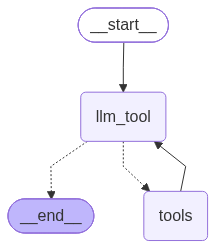

In [123]:
from IPython.display import Image, display
display(Image(react.get_graph().draw_mermaid_png()))

In [124]:
messages = [HumanMessage(content="Add 10 and 14. Multiply the output by 2. Divide the output by 5")]
messages = react.invoke({"messages": messages})

In [125]:
for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

Add 10 and 14. Multiply the output by 2. Divide the output by 5
================================== Ai Message ==================================
Tool Calls:
  add (fc_cefce2ba-2924-450a-beb8-79d6ef6ac1b0)
 Call ID: fc_cefce2ba-2924-450a-beb8-79d6ef6ac1b0
  Args:
    a: 10
    b: 14
================================= Tool Message =================================
Name: add

24
================================== Ai Message ==================================

9.6


In [127]:
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()
react=builder.compile(checkpointer=memory)


In [131]:
config={"configurable":{"thread_id":"1"}}

In [132]:
messages = [HumanMessage(content="Add 3 and 4.")]


messages = react.invoke({"messages": messages},config)
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Add 3 and 4.
================================== Ai Message ==================================
Tool Calls:
  add (fc_7a135553-4334-44f9-8e4c-91d62a9ffa1f)
 Call ID: fc_7a135553-4334-44f9-8e4c-91d62a9ffa1f
  Args:
    a: 3
    b: 4
================================= Tool Message =================================
Name: add

7
================================== Ai Message ==================================

The sum of 3 and 4 is **7**.


In [133]:
messages=HumanMessage(content="multiply by 3")

messages=react.invoke({"messages":messages},config)
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Add 3 and 4.
================================== Ai Message ==================================
Tool Calls:
  add (fc_7a135553-4334-44f9-8e4c-91d62a9ffa1f)
 Call ID: fc_7a135553-4334-44f9-8e4c-91d62a9ffa1f
  Args:
    a: 3
    b: 4
================================= Tool Message =================================
Name: add

7
================================== Ai Message ==================================

The sum of 3 and 4 is **7**.
================================ Human Message =================================

multiply by 3
================================== Ai Message ==================================
Tool Calls:
  mul (fc_bc103229-5451-4b96-8531-70e9fa6390ed)
 Call ID: fc_bc103229-5451-4b96-8531-70e9fa6390ed
  Args:
    a: 7
    b: 3
================================= Tool Message =================================
Name: mul

21
================================== Ai Message =============================

In [139]:
config2={"configurable":{"thread_id":"2"}}

In [140]:
messages = [HumanMessage(content="Add 10 and 14. Multiply the output by 2. Divide the output by 5")]
messages = react.invoke({"messages": messages},config2)

In [141]:
for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

Add 10 and 14. Multiply the output by 2. Divide the output by 5
================================== Ai Message ==================================
Tool Calls:
  add (fc_c02b493b-0b54-4fba-b792-48a2c6d92aaa)
 Call ID: fc_c02b493b-0b54-4fba-b792-48a2c6d92aaa
  Args:
    a: 10
    b: 14
================================= Tool Message =================================
Name: add

24
================================== Ai Message ==================================
Tool Calls:
  mul (fc_26101eac-5717-4df0-9798-2da8ca62ca67)
 Call ID: fc_26101eac-5717-4df0-9798-2da8ca62ca67
  Args:
    a: 24
    b: 2
================================= Tool Message =================================
Name: mul

48
================================== Ai Message ==================================
Tool Calls:
  divide (fc_a1ac46a1-c790-4e84-a1e2-44ee4cfdf69c)
 Call ID: fc_a1ac46a1-c790-4e84-a1e2-44ee4cfdf69c
  Args:
    a: 48
    b: 5
======